✅ Dataset generated successfully:
   Hours_Studied  Attendance  Previous_Score  Final_Score
0            4.4        52.6            50.1         48.0
1            9.6        76.6            56.7         67.7
2            7.6        77.0            50.6         65.2
3            6.4        81.9            45.3         56.7
4            2.4        86.3            47.2         44.6


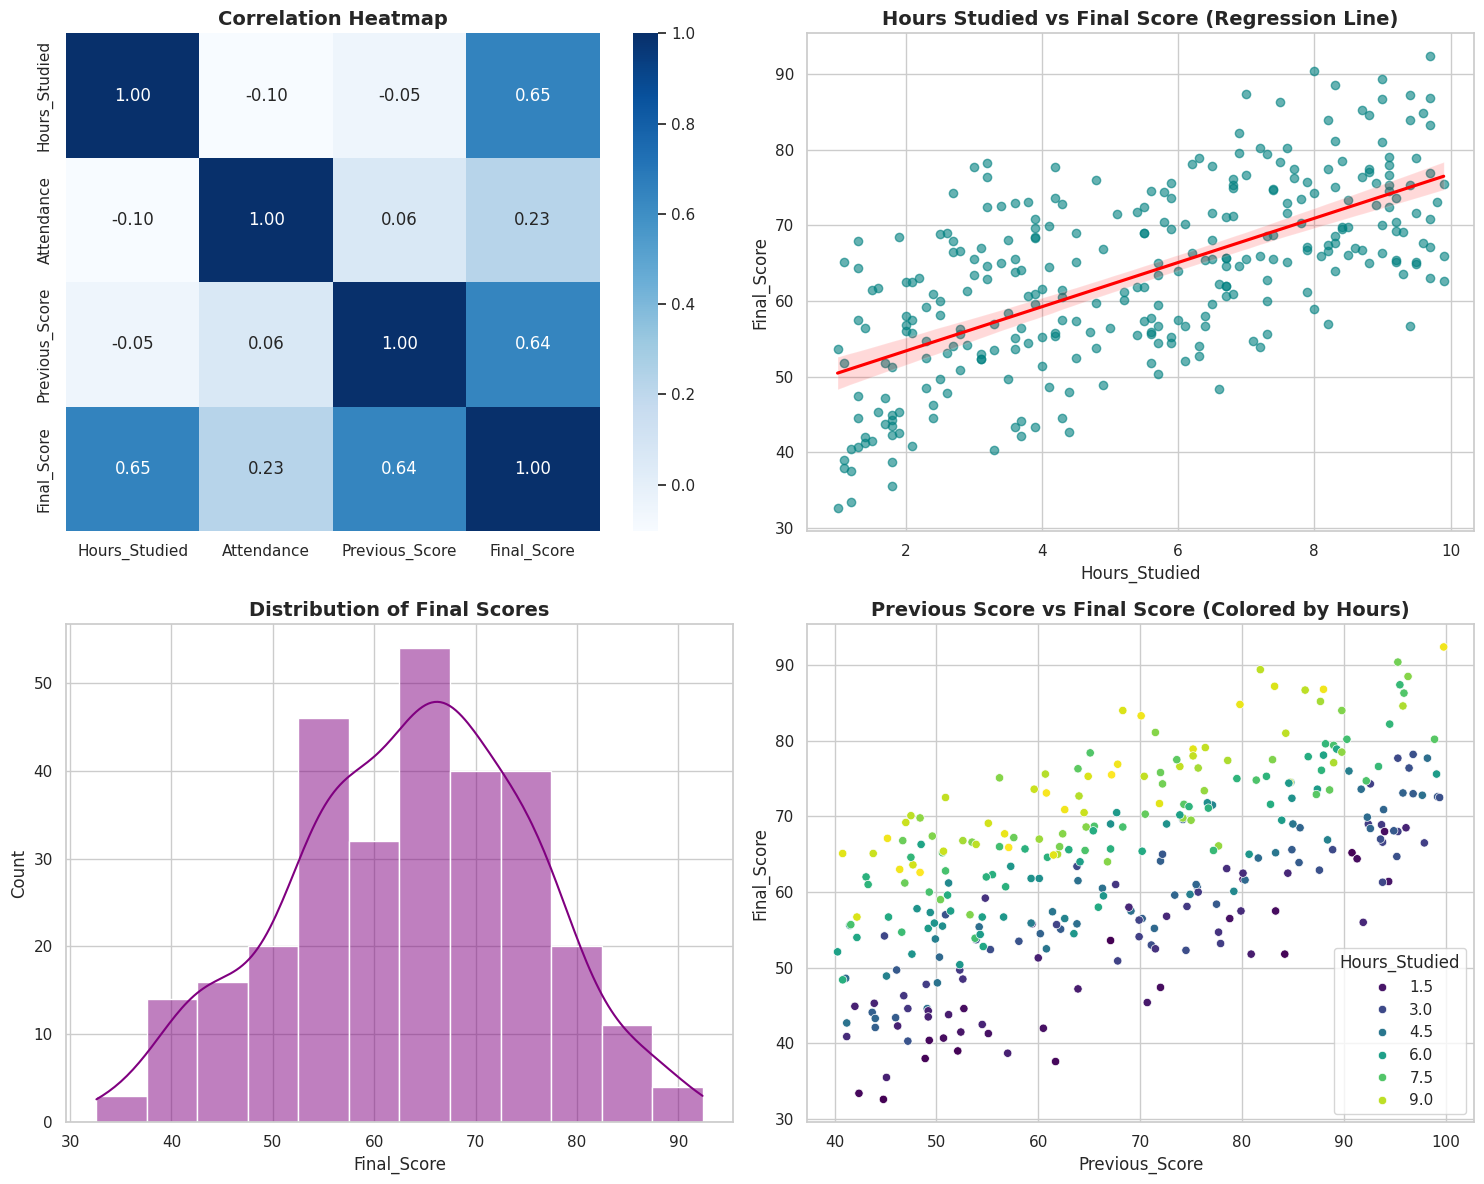


📊 Model Performance:
• R-squared (Accuracy): 89.34%
• Mean Absolute Error (MAE): 2.93 Points
• Mean Squared Error (MSE): 12.31

🎓 STUDENT PERFORMANCE & ADVISORY REPORT
• Predicted Final Score: 54.7 / 100

💡 Actionable Insights & Recommendations:
⚠️ The student is 30.3 points away from the desired target (85%).
 1. Increase weekly study time by ~9.5 hours to bridge the gap.
 2. Attendance is low; increasing attendance to 90%+ will directly improve outcomes.


In [1]:
# ==========================================
# 1. Imports and Dataset Generation
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Generate a realistic synthetic dataset of 300 students
np.random.seed(42)
n_samples = 300

hours = np.random.uniform(1, 10, n_samples)
attendance = np.random.uniform(50, 100, n_samples)
prev_score = np.random.uniform(40, 100, n_samples)

# Formula simulating real-world correlation with Gaussian noise
final_score = (3.2 * hours) + (0.2 * attendance) + (0.45 * prev_score) + np.random.normal(0, 3, n_samples)
final_score = np.clip(final_score, 0, 100) # Keep scores bounded between 0 and 100

data = pd.DataFrame({
    'Hours_Studied': np.round(hours, 1),
    'Attendance': np.round(attendance, 1),
    'Previous_Score': np.round(prev_score, 1),
    'Final_Score': np.round(final_score, 1)
})

print("✅ Dataset generated successfully:")
print(data.head())

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# A) Correlation Heatmap
sns.heatmap(data.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# B) Hours Studied vs Final Score Regression Plot
sns.regplot(data=data, x='Hours_Studied', y='Final_Score', ax=axes[0, 1],
            color='teal', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0, 1].set_title('Hours Studied vs Final Score (Regression Line)', fontsize=14, fontweight='bold')

# C) Distribution of Final Scores
sns.histplot(data['Final_Score'], kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Final Scores', fontsize=14, fontweight='bold')

# D) Previous Score vs Final Score (Colored by Hours Studied)
sns.scatterplot(data=data, x='Previous_Score', y='Final_Score', hue='Hours_Studied', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Previous Score vs Final Score (Colored by Hours)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 3. Model Training & Evaluation
# ==========================================
X = data[['Hours_Studied', 'Attendance', 'Previous_Score']]
y = data['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor for high predictive performance
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) * 100

print("\n📊 Model Performance:")
print(f"• R-squared (Accuracy): {r2:.2f}%")
print(f"• Mean Absolute Error (MAE): {mae:.2f} Points")
print(f"• Mean Squared Error (MSE): {mse:.2f}")

# ==========================================
# 4. Interactive Advisory System (Actionable Insights)
# ==========================================
def student_performance_advisor(hours_studied, attendance_pct, previous_score, target_score=85):
    """
    Predicts student score and generates personalized actionable recommendations.
    """
    input_data = pd.DataFrame({
        'Hours_Studied': [hours_studied],
        'Attendance': [attendance_pct],
        'Previous_Score': [previous_score]
    })

    predicted_score = model.predict(input_data)[0]

    print("\n" + "="*50)
    print("🎓 STUDENT PERFORMANCE & ADVISORY REPORT")
    print("="*50)
    print(f"• Predicted Final Score: {predicted_score:.1f} / 100")

    print("\n💡 Actionable Insights & Recommendations:")

    if predicted_score >= target_score:
        print(f" Great performance! The student is on track to achieve the target ({target_score}%+).")
    else:
        gap = target_score - predicted_score
        print(f"⚠️ The student is {gap:.1f} points away from the desired target ({target_score}%).")

        # Actionable recommendations based on feature importance
        needed_hours_boost = round(gap / 3.2, 1)
        print(f" 1. Increase weekly study time by ~{needed_hours_boost} hours to bridge the gap.")

        if attendance_pct < 85:
            print(" 2. Attendance is low; increasing attendance to 90%+ will directly improve outcomes.")

        if previous_score < 60:
            print(" 3. Fundamental review of earlier concepts is required to reinforce core understanding.")

    print("="*50)

# Sample test execution
student_performance_advisor(hours_studied=4.0, attendance_pct=75.0, previous_score=60.0, target_score=85)

In [5]:
# ==========================================
# 5. Colab Interactive Controls
# ==========================================
#@title 🎛️ Interactive Student Predictor
Hours_Studied = 8 # @param {"type":"slider","min":1,"max":100,"step":0.5}
Attendance_Percentage = 80 #@param {type:"slider", min:50, max:100, step:5}
Previous_Score = 70 #@param {type:"slider", min:40, max:100, step:5}
Target_Score = 80 #@param {type:"number"}

student_performance_advisor(Hours_Studied, Attendance_Percentage, Previous_Score, Target_Score)


🎓 STUDENT PERFORMANCE & ADVISORY REPORT
• Predicted Final Score: 74.9 / 100

💡 Actionable Insights & Recommendations:
⚠️ The student is 5.1 points away from the desired target (80%).
 1. Increase weekly study time by ~1.6 hours to bridge the gap.
 2. Attendance is low; increasing attendance to 90%+ will directly improve outcomes.
